# AIML428 - Assignment1, Step 5 Pre-Trained Word Embedding
* Using Fasttext

In [10]:
import keras
import matplotlib.pyplot as plt
import os
import pandas as pd
import torch
from IPython.display import Markdown, display
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from keras import layers
from keras.models import Sequential
from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag
from nltk.tokenize import word_tokenize
from sklearn import preprocessing
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.model_selection import train_test_split


In [11]:
def tableHeader():
    doc = "|Algorithm| label | accuracy | precision | recall | f1 |\n"
    doc += "| --- | --- | --- | --- |--- | --- |\n"
    return doc

def tableScore(labels, doc, prefix=None, y_true=None, y_prediction=None):
    rows = ""
    accuracy = accuracy_score(y_true, y_prediction)
    precisions = precision_score(y_true, y_prediction, labels=labels, average=None)
    recalls = recall_score(y_true, y_prediction, labels=labels, average=None)
    f1s = f1_score(y_true, y_prediction, labels=labels, average=None)
    for label, precision, recall, f1 in zip(labels, precisions, recalls, f1s):
        rows += f"| {prefix} | {label} | {accuracy:.4g} | {precision:.4g} | {recall:.4g} | {f1:.4g} |\n"
        prefix = " "
    return doc + rows

def tableFooter(doc):
    display(Markdown(doc))

def report(string):
    display(Markdown(string))

enable_debug = True

def debug(string):
    if (enable_debug):
        print(string)

## Try to use a GPU for go faster juice

In [12]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Metal (GPU) is available")
else:
    device = torch.device("cpu")
    print("GPU not available, using CPU")

# Encourage Keras to use Torch, and to use the GPU.
os.environ["KERAS_BACKEND"] = "torch"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

Metal (GPU) is available


## Magic to download wordnet

In [13]:
import nltk
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/jepollock/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/jepollock/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/jepollock/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

## Load the data.

In [14]:
df_csv = pd.read_csv('bbc_converted.csv')

feature_columns = ['text']
target_column = 'category'

X_csv = df_csv[feature_columns]
Y_csv = df_csv[target_column]
# unique converts to an NDArray, so the sort needs to happen first.
labels = Y_csv.sort_values().unique()
print(labels)

['business' 'entertainment' 'politics' 'sport' 'tech']


In [15]:
# https://xkcd.com/221/ - 4 is overused
random_seed = 221

In [16]:
# Data already loaded
# X_csv is the CSV text data
# Y_csv is the CSV labels - the sorted label set.
debug(X_csv)
debug(Y_csv)
debug(labels)

                                                   text
0     Musicians to tackle US red tape Musicians grou...
1     U2 s desire to be number one U2 who have won t...
2     Rocker Doherty in on stage fight Rock singer P...
3     Snicket tops US box office chart The film adap...
4     Ocean s Twelve raids box office Ocean s Twelve...
...                                                 ...
2220  Warning over Windows Word files Writing a Micr...
2221  Fast lifts rise into record books Two high spe...
2222  Nintendo adds media playing to DS Nintendo is ...
2223  Fast moving phone viruses appear Security firm...
2224  Hacker threat to Apple s iTunes Users of Apple...

[2225 rows x 1 columns]
0       entertainment
1       entertainment
2       entertainment
3       entertainment
4       entertainment
            ...      
2220             tech
2221             tech
2222             tech
2223             tech
2224             tech
Name: category, Length: 2225, dtype: object
['business' 'ente

## Data preprocessing - lemmatization
* Lemmatization is a preprocessing step, it is applied to the dataset, not learned from Training and applied to Test.

In [17]:
# From Part-of-speech tagging guidelines for the Penn Treebank Project.
# https://catalog.ldc.upenn.edu/docs/LDC99T42/tagguid1.pdf
tag_dict = {"J": "a", "R":"r", "V": "v"}

def treebank_to_wordnet(treebank_tag:str):
  # n - nouns
  # a - adjective
  # r - adverb
  # s - satellite adjectives
  # default is h
  if (treebank_tag.startswith("WRB")):
      return "r"
  return tag_dict.get(treebank_tag[0], "n")

lemmatizer = WordNetLemmatizer()

def lemmatizeText(text:str):
    accum = []
    tagged_values = pos_tag(word_tokenize(text))
    for t, pos in tagged_values:
        wordnet_tag = treebank_to_wordnet(pos)
        #debug(f"from ({t},{pos}, {wordnet_tag})")
        lemmatized = lemmatizer.lemmatize(word=t,pos=wordnet_tag)
        accum.append(lemmatized)
    result = ' '.join(accum)
    #debug(result)
    return result

X_lemmatized = pd.DataFrame()
X_lemmatized['text'] = X_csv.text.apply(lemmatizeText)

X_lemmatized

,text
0,Musicians to tackle US red tape Musicians grou...
1,U2 s desire to be number one U2 who have win t...
2,Rocker Doherty in on stage fight Rock singer P...
3,Snicket top US box office chart The film adapt...
4,Ocean s Twelve raid box office Ocean s Twelve ...
...,...
2220,Warning over Windows Word file Writing a Micro...
2221,Fast lift rise into record book Two high speed...
2222,Nintendo add medium play to DS Nintendo be rel...
2223,Fast move phone virus appear Security firm be ...


## Test/Train Split

In [18]:
X_train, X_test, Y_train, Y_test = train_test_split(X_lemmatized, Y_csv, test_size= 0.3, random_state=random_seed)

debug(f"X columns: {X_train.columns}")
debug(f"X.head: {X_train.text.head(1)}")
debug(f"Y.head: {Y_train.head(1)}")
#debug(f"result: {X_train[0]}")

X columns: Index(['text'], dtype='object')
X.head: 1187    Edwards tip Idowu for Euro gold World outdoor ...
Name: text, dtype: object
Y.head: 1187    sport
Name: category, dtype: object


## Create Validation Set

We do it here to make it easier. Tensors can't use the same functions, and the ones they have are interesting in other ways.

In [19]:
X_train_wv, X_validation, Y_train_wv, Y_validation = (
   train_test_split(X_train, Y_train, test_size=0.2, random_state=random_seed))

## Use oversampling for balance - only the training set

SMOTE and ADASYN only work on numeric data. Could do it by converting to vector space too, but that is too much for for today.

In [20]:
random_oversampler = RandomOverSampler(random_state=random_seed)
X_train_rs, Y_train_rs = random_oversampler.fit_resample(X_train_wv, Y_train_wv)

debug(sorted(Counter(Y_train_rs.tolist()).items()))
debug(X_train_rs.shape)
debug(Y_train_rs.shape)

[('business', 285), ('entertainment', 285), ('politics', 285), ('sport', 285), ('tech', 285)]
(1425, 1)
(1425,)


## Encode the label

Train on all the _training_ values, but apply it to the _train/_validation variables, and the _test variables.

In [21]:
# label encode the target variable
encoder = preprocessing.OneHotEncoder(sparse_output=False)

encoder.fit(Y_train.values.reshape(-1, 1))
Y_train_enc = encoder.transform(Y_train_rs.values.reshape(-1, 1))
Y_validation_enc = encoder.transform(Y_validation.values.reshape(-1, 1))
Y_test_enc = encoder.transform(Y_test.values.reshape(-1, 1))

debug(f"Y_train_enc.shape: {Y_train_enc.shape}")


Y_train_enc.shape: (1425, 5)


# Vectorization to have an index.

In [22]:
from tensorflow.keras.layers import TextVectorization

# This is the bit we are going to change with fasttext.

max_tokens = 50000  # Maximum vocab size.
max_len = 70  # Sequence length to pad the outputs to.

vectorize_layer = TextVectorization(
    max_tokens=max_tokens,
    output_mode='int',
    output_sequence_length=max_len)

# Adapt the layer to the training text.
# Create a dict and go.
vectorize_layer.adapt(X_train)
train_vocabulary = vectorize_layer.get_vocabulary()
X_train_vec = vectorize_layer(X_train_rs)
X_test_vec = vectorize_layer(X_test)
X_validation_vec = vectorize_layer(X_validation)

X_train_vec

<tf.Tensor: shape=(1425, 70), dtype=int64, numpy=
array([[ 1717, 16429,    12, ...,    78,  8389,    12],
       [ 2532,  3341,     4, ..., 21954,  3341,    13],
       [  520,  2653,     5, ...,     2,   448,   387],
       ...,
       [  520,  2653,     5, ...,     2,   448,   387],
       [ 1443,   499,     4, ...,   282,    24,   132],
       [  615,  1519,  2416, ...,    21,    63,     2]])>


## Vectorize the sets
* train on the entire dataset
* then vectorize test, train and validation independently

In [25]:
# map the words to their indices. zip combines iterators, so this maps the word to the TextVectorization int value.
word_index = dict(zip(train_vocabulary, range(len(train_vocabulary))))

# confirmed they're the same.
debug(vectorize_layer(["outdoor"]))
debug(word_index["outdoor"])

# READ THIS: https://realpython.com/python-keras-text-classification/#using-pretrained-word-embeddings
# Continue with https://keras.io/examples/nlp/pretrained_word_embeddings/

tf.Tensor(
[[3470    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0]], shape=(1, 70), dtype=int64)
3470


In [7]:
import fasttext

# Model downloaded from: https://fasttext.cc/docs/en/pretrained-vectors.html
model = fasttext.load_model('data/crawl-300d-2M-subword.bin')
dimensions=300






model.get_word_vector("wombat").shape

(300,)

## Train the CNN using
* Data is Lemmatized
* Data has a validation set
* Training data was oversampled.
* Uses Early Stopping

In [91]:
from keras.src.initializers import RandomNormal

vocab_size = len(train_vocabulary)+1
print("vocab_size:", vocab_size)
maxDocumentLength = 70
earlyStoppingMinDelta = 0.0001
earlyStoppingPatience = 8
epochs=500 # demonstrate early stopping works.

model = Sequential()

model.add(layers.Embedding(
    embeddings_initializer=RandomNormal(mean=0.0, stddev=1.0, seed=random_seed),
    input_dim=vocab_size,
    output_dim=50))
model.build((None, maxDocumentLength)) # build the first layer with the specific input_length

model.add(layers.Conv1D(filters=128, kernel_size=5, activation='relu'))

model.add(layers.GlobalAveragePooling1D())
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(Y_train_enc.shape[1], activation='sigmoid'))

model.summary()

early_stopping_callback = keras.callbacks.EarlyStopping(monitor="val_loss",
                                                        min_delta=earlyStoppingMinDelta,
                                                        restore_best_weights=True,
                                                        patience=earlyStoppingPatience)

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['acc'])

print(X_train_vec.shape)
print(Y_train_enc.shape)
print(X_validation_vec.shape)
print(Y_validation_enc.shape)

history = model.fit(X_train_vec,
                    Y_train_enc,
                    callbacks=[early_stopping_callback],
                    epochs=epochs,
                    batch_size=512,
                    validation_data=(X_validation_vec, Y_validation_enc),
                    verbose=1)




vocab_size: 22098


Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_36 (Embedding)        │ (None, 70, 50)         │     1,104,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_36 (Conv1D)              │ (None, 66, 128)        │        32,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_36     │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 16)             │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,139,177 (4.35 MB)

 Trainable params: 1,139,177 (4.35 MB)

 Non-trainable params: 0 (0.00 B)

(1425, 70)
(1425, 5)
(312, 70)
(312, 5)
Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step - acc: 0.2000 - loss: 0.6685 - val_acc: 0.1731 - val_loss: 0.6209
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - acc: 0.1993 - loss: 0.5968 - val_acc: 0.1731 - val_loss: 0.5699
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.1993 - loss: 0.5498 - val_acc: 0.1731 - val_loss: 0.5343
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - acc: 0.1986 - loss: 0.5197 - val_acc: 0.1763 - val_loss: 0.5174
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - acc: 0.2035 - loss: 0.5058 - val_acc: 0.1955 - val_loss: 0.5123
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - acc: 0.2554 - loss: 0.5016 - val_acc: 0.2821 - val_loss: 0.5111
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.3368 - loss: 0.5002 - val_acc: 0.2276 - val_loss: 0.5077
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - acc: 0.2849 - loss: 0.4960 - val_acc: 0.2212 - val_loss: 0.5023
Epoch 9/500
3/3 ━━━━━━━━━━━━━━━

dict_keys(['acc', 'loss', 'val_acc', 'val_loss'])


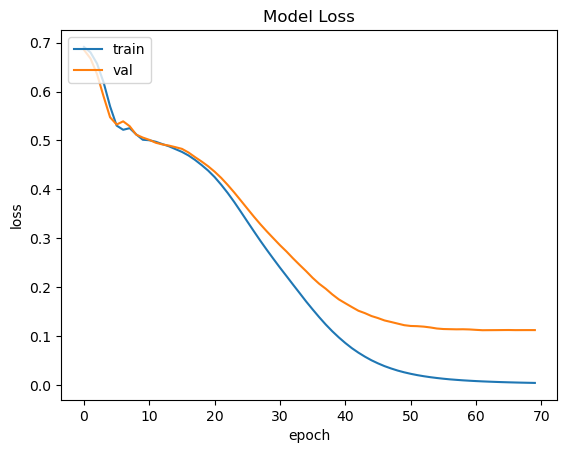

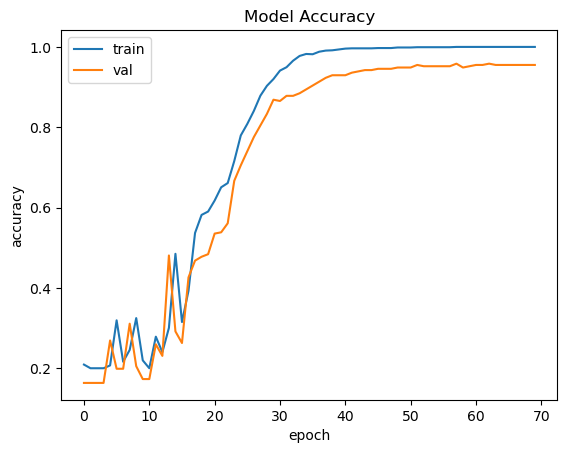

In [86]:

debug(history.history.keys())

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])

plt.title('Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

## Test the model

In [89]:
(test_loss, test_accuracy) = model.evaluate(X_test_vec, Y_test_enc)

report(f"**test loss:** {test_loss}")
report(f"**test accuracy:** {test_accuracy}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9506 - loss: 0.1160 


**test loss:** 0.11596519500017166

**test accuracy:** 0.9505987763404846